In [1]:
import numpy as np
import matplotlib.pyplot as plt

from classes.pss import power_spectrum
from networkx import petersen_graph, laplacian_matrix, draw_kamada_kawai

# Petersen graph example

## Petersen graph

A highly symmetric graph; strongly regular.

In [2]:
G = petersen_graph()
L = laplacian_matrix(G)

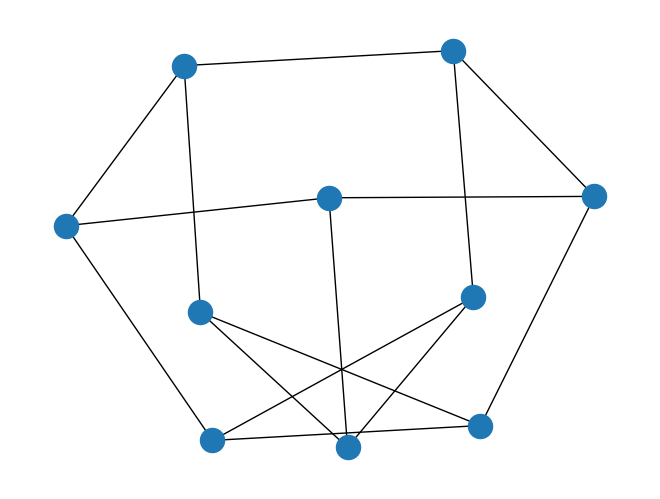

In [3]:
draw_kamada_kawai(G)

## Compute power spectrum of vertex functions with Laplacian

In [4]:
ps = power_spectrum(eigendecomposition_provided = False)
ps.fit(L.todense())

In [5]:
vertex_functions = np.eye(len(G))
eigenvalues, masses = ps.transform(vertex_functions)

/Users/sjoh3864/Code/Oxford/PSsig/classes/pss.py:90: RuntimeWarning: divide by zero encountered in matmul
  projection = self.eigenvectors_ @ f #projection onto eigenspace
/Users/sjoh3864/Code/Oxford/PSsig/classes/pss.py:90: RuntimeWarning: overflow encountered in matmul
  projection = self.eigenvectors_ @ f #projection onto eigenspace
/Users/sjoh3864/Code/Oxford/PSsig/classes/pss.py:90: RuntimeWarning: invalid value encountered in matmul
  projection = self.eigenvectors_ @ f #projection onto eigenspace


## Visualise as measures

Each stem represents a dirac mass $\delta_\lambda$ on an eigenvalue, and the height of the stem corresponds to the weight accorded to the dirac mass. Due to the symmetry, all vertices have the same power spectrum

In [6]:
cmap = plt.cm.tab10  
cmaplist = [cmap(i) for i in range(len(G))]

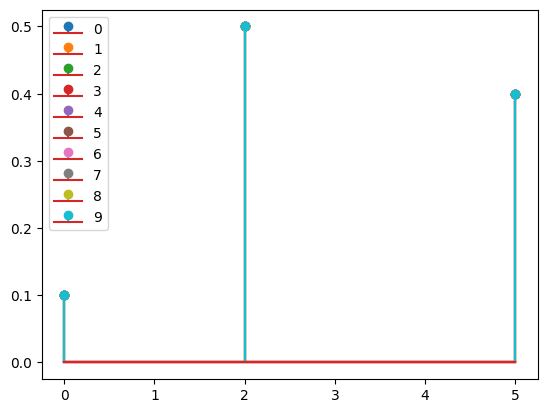

In [7]:
for j, m in enumerate(masses.T):
    plt.stem(eigenvalues, m, label = str(j), linefmt= cmaplist[j])
plt.legend()

## Compute quantiles as measures

In [8]:
q = np.linspace(0,1, 1001) #percents

quantile_functions = np.array([np.quantile(eigenvalues, q, method= 'inverted_cdf', weights = m) for m in masses.T])


Plot quantile function of first vertex

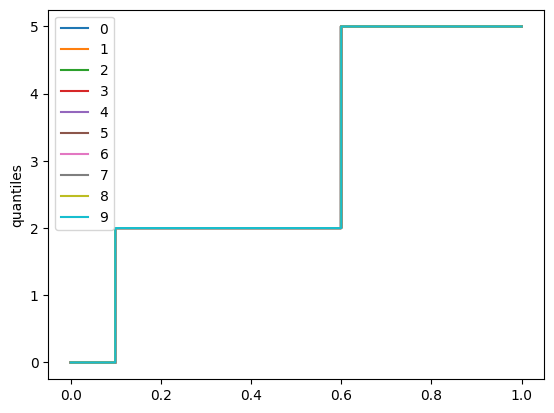

In [9]:
for j, qf in enumerate(quantile_functions):
    plt.step(q, quantile_functions[j], c = cmaplist[j], label = str(j))
plt.ylabel('quantiles')
plt.legend()

## Testing stability

We perturb the Laplacian with some noise and examine how the power spectrum signatures change.

In [11]:
noise = np.random.uniform(-1,1, size = (len(G), len(G)))
noise += noise.T #make symmetric
noise /= 10 # rescale

ps_noisy = power_spectrum(eigendecomposition_provided = False)
ps_noisy.fit(L.todense() + noise)
eigenvalues_noisy, masses_noisy = ps_noisy.transform(vertex_functions)

quantile_functions_noisy = np.array([np.quantile(eigenvalues_noisy, q, method= 'inverted_cdf', weights = m) for m in masses_noisy.T])


### Visualise noisy version
We note that the noise disrupts the symmetry and the dirac masses concentrated on 3 eigenvalues now splits! However, the perturbation to the quantile function remain 

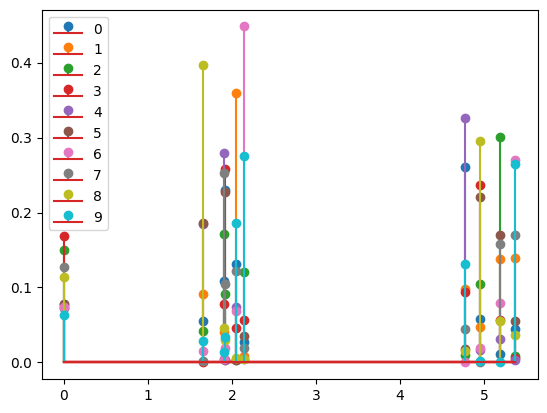

In [12]:
for j, m in enumerate(masses_noisy.T):
    plt.stem(eigenvalues_noisy, m, label = str(j), linefmt= cmaplist[j])
plt.legend()

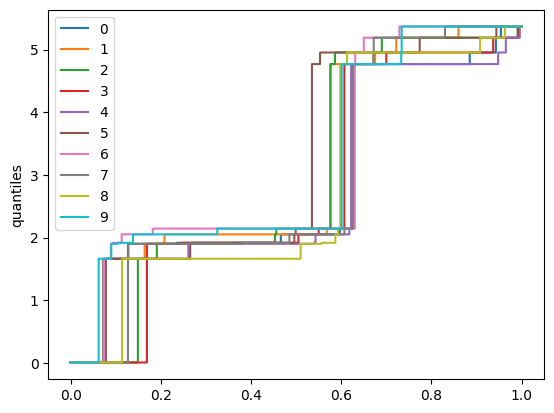

In [13]:
for j, qf in enumerate(quantile_functions):
    plt.step(q, quantile_functions_noisy[j], c = cmaplist[j], label = str(j))
plt.ylabel('quantiles')
plt.legend()